## Generalised Linear Regression Exercise

### Benjamin Bezzina 08/09/2026

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln  # for log(y!) = gammaln(y+1)
from scipy.optimize import minimize

bird_data = np.genfromtxt('data/bird_count.csv', delimiter=',', skip_header=1)

In [76]:
year = bird_data[:, 1]
count = bird_data[:, 0] 

year_centered = year - np.mean(year)
year_centered

array([ 5.30769231,  4.30769231, -3.69230769,  0.30769231,  2.30769231,
        6.30769231, -5.69230769, -0.69230769,  1.30769231, -1.69230769,
       -6.69230769, -4.69230769,  3.30769231])

In [77]:
def log_likelihood_poission_glm(params, x, y):
    """
    log L(beta0, beta1) = sum_i [ y_i * eta_i - exp(eta_i) - log(y_i!) ]
    where eta_i = beta0 + beta1 * x_i  (= log(lambda_i))
    """
    beta0, beta1 = params
    eta = beta0 + beta1 * x
    lam = np.exp(eta)
    log_lik = np.sum(y * eta - lam - gammaln(y + 1.0))
    return -log_lik

In [78]:
initial_params = np.array([np.log(np.mean(count)), 0.0])

# Minimize the negative log-likelihood
result = minimize(
    log_likelihood_poission_glm,
    initial_params,
    args=(year_centered, count),
    method='BFGS'
)

# Estimated parameters
beta0_hat, beta1_hat = result.x

print("Estimated beta0:", beta0_hat)
print("Estimated beta1:", beta1_hat)
print("Converged:", result.success)

Estimated beta0: 2.1082121895815042
Estimated beta1: -0.03244316662568162
Converged: True


In [79]:
# Fitted linear predictor
eta_hat = beta0_hat + beta1_hat * year_centered

# Fitted Poisson mean
lambda_hat = np.exp(eta_hat)

print(lambda_hat)

[ 6.93106751  7.15962074  9.28130668  8.15172594  7.63958547  6.70981028
  9.90350442  8.4205306   7.8915022   8.69819915 10.2300743   9.58735948
  7.39571055]


In [80]:
# Generate three hypothetical samples
sample1 = np.random.poisson(lambda_hat)
sample2 = np.random.poisson(lambda_hat)
sample3 = np.random.poisson(lambda_hat)

print("Sample 1:", sample1)
print("Sample 2:", sample2)
print("Sample 3:", sample3)

Sample 1: [ 5  7  9 12  7  8 18 10  7  7  6 11 11]
Sample 2: [ 2  7 11  5  9  6  7  7 12 10 14  7 10]
Sample 3: [ 3  4 11 11  6  4 11 10 12  7 13 17  5]


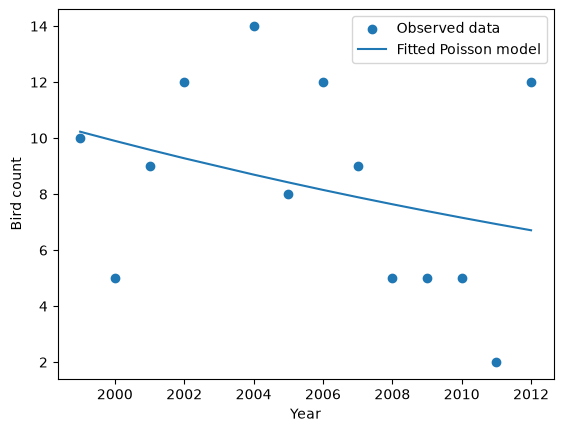

In [81]:
# Plot observed data and fitted model
order = np.argsort(year)

plt.scatter(year, count, label='Observed data')
plt.plot(
    year[order],
    lambda_hat[order],
    label='Fitted Poisson model'
)

plt.xlabel('Year')
plt.ylabel('Bird count')
plt.legend()
plt.show()